In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Fix path - go one level up from notebooks folder
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()

# Paths
train_real = os.path.join(base_dir, 'data/raw/train/REAL')
train_fake = os.path.join(base_dir, 'data/raw/train/FAKE')
test_real = os.path.join(base_dir, 'data/raw/test/REAL')
test_fake = os.path.join(base_dir, 'data/raw/test/FAKE')

# Verify paths exist
for path in [train_real, train_fake, test_real, test_fake]:
    print(f"{'OK' if os.path.exists(path) else 'NOT FOUND'}: {path}")

OK: c:\Users\shabe\Downloads\visual-misinformation-detector\data/raw/train/REAL
OK: c:\Users\shabe\Downloads\visual-misinformation-detector\data/raw/train/FAKE
OK: c:\Users\shabe\Downloads\visual-misinformation-detector\data/raw/test/REAL
OK: c:\Users\shabe\Downloads\visual-misinformation-detector\data/raw/test/FAKE


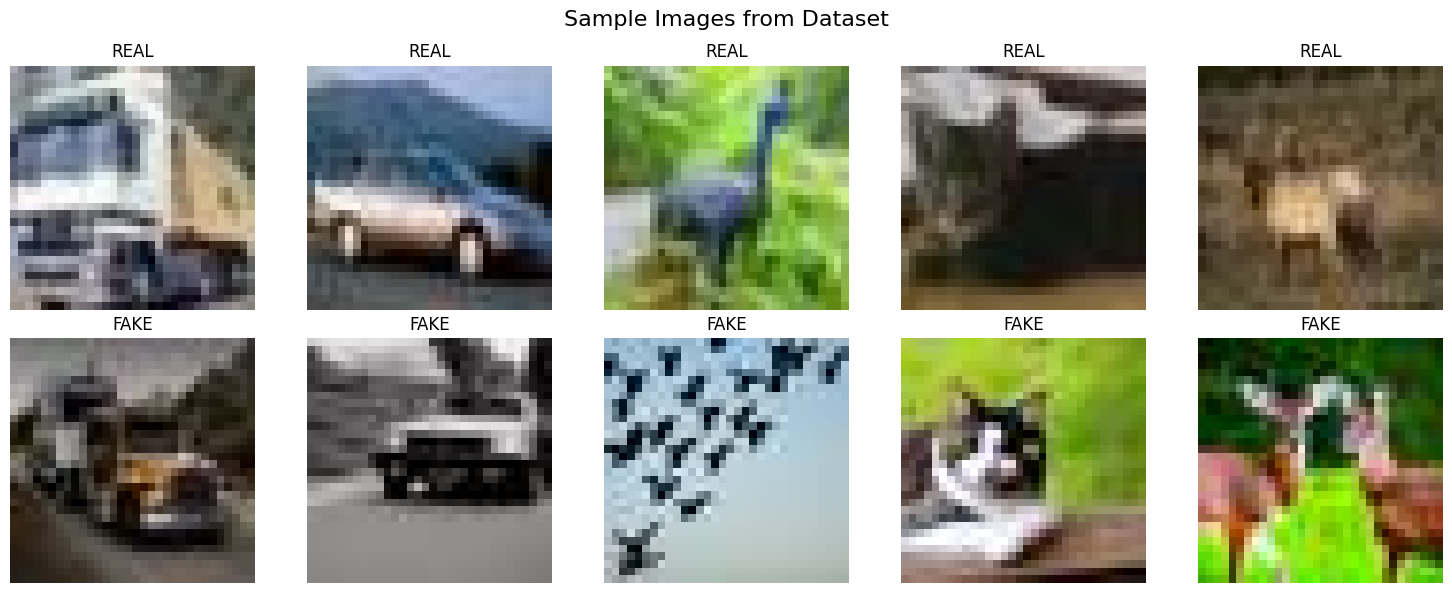

Done!


In [3]:
# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=16)

# Top row: REAL images
real_imgs = os.listdir(train_real)[:5]
for i, img_name in enumerate(real_imgs):
    img = Image.open(os.path.join(train_real, img_name))
    axes[0, i].imshow(img)
    axes[0, i].set_title('REAL')
    axes[0, i].axis('off')

# Bottom row: FAKE images
fake_imgs = os.listdir(train_fake)[:5]
for i, img_name in enumerate(fake_imgs):
    img = Image.open(os.path.join(train_fake, img_name))
    axes[1, i].imshow(img)
    axes[1, i].set_title('FAKE')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'outputs/sample_images.png'))
plt.show()
print('Done!')

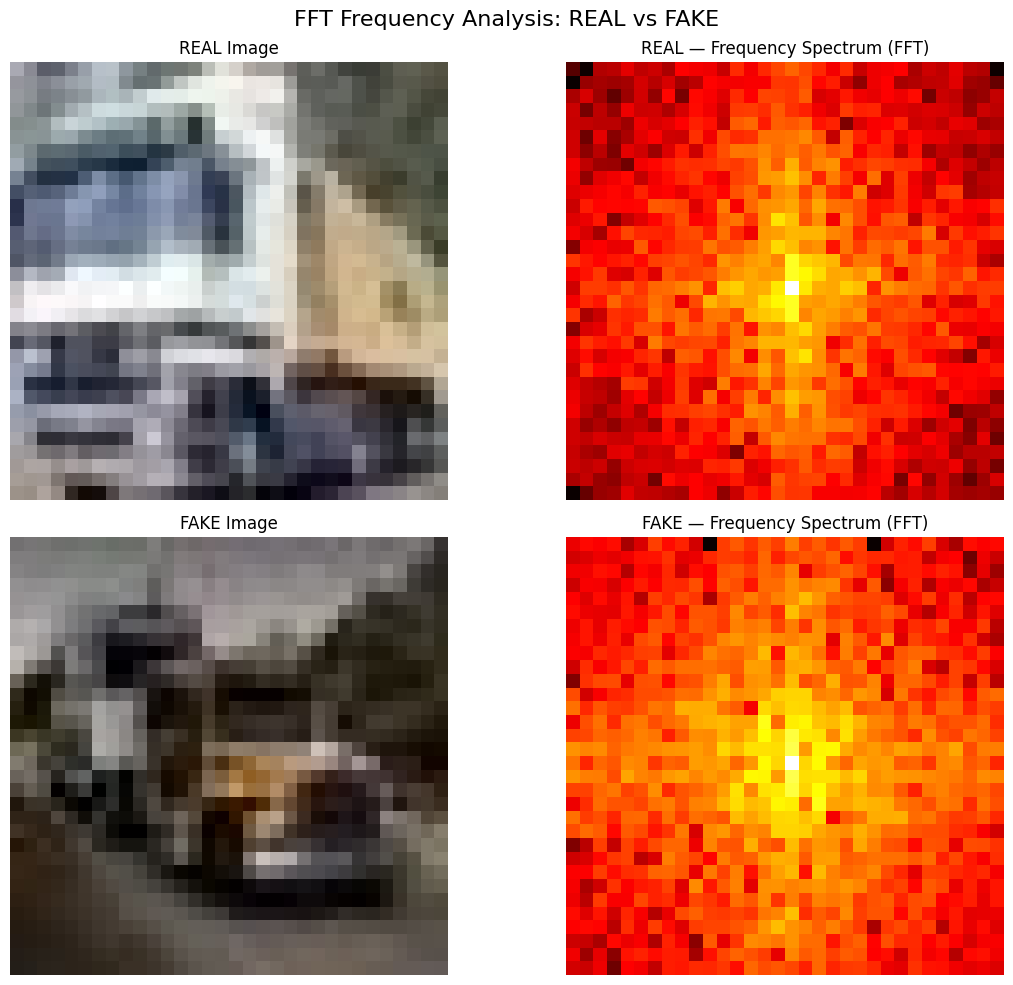

Done!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

def compute_fft(img_path):
    img = Image.open(img_path).convert('L')  # convert to grayscale
    img_array = np.array(img, dtype=np.float32)
    fft = np.fft.fft2(img_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log(np.abs(fft_shift) + 1)
    return magnitude

# Pick one real and one fake image
real_img_path = os.path.join(train_real, os.listdir(train_real)[0])
fake_img_path = os.path.join(train_fake, os.listdir(train_fake)[0])

# Plot original + FFT side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('FFT Frequency Analysis: REAL vs FAKE', fontsize=16)

# Real image
real_img = Image.open(real_img_path)
axes[0, 0].imshow(real_img)
axes[0, 0].set_title('REAL Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(compute_fft(real_img_path), cmap='hot')
axes[0, 1].set_title('REAL — Frequency Spectrum (FFT)')
axes[0, 1].axis('off')

# Fake image
fake_img = Image.open(fake_img_path)
axes[1, 0].imshow(fake_img)
axes[1, 0].set_title('FAKE Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(compute_fft(fake_img_path), cmap='hot')
axes[1, 1].set_title('FAKE — Frequency Spectrum (FFT)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'outputs/fft/fft_comparison.png'))
plt.show()
print('Done!')